# Nigerian SME Segmentation - Exploratory Data Analysis

**Dataset:** World Bank Nigeria Enterprise Survey 2025  
**Firms:** 1,043 | **Final features:** 21  

This notebook covers feature selection, data cleaning, encoding, imputation, and distribution analysis.  

---

## 1. Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 2. Feature Selection and Data Load

The full dataset has 337 columns. We do not need all of them for clustering.  
Feature selection was done by reading the variable labels embedded in the Stata file and picking columns that cover five dimensions of firm behaviour:

- **Scale and performance** - employees, sales, sales 3 years ago, capacity utilization
- **Financial structure** - working capital sources, loan access
- **Operations and market** - export share, import inputs, firm age, manager experience
- **Innovation and technology** - quality certification, new products, R&D, website, foreign tech
- **Business environment perception** - obstacle ratings for finance, electricity, tax, informal competition
- **Gender inclusion** - women among owners (`b4`), women employees (`l5`)

Firm size (`a6a`) was excluded intentionally. The clustering should discover size naturally from employees and sales rather than having it pre-labelled.

In [23]:
df = pd.read_stata('../data/raw/Nigeria-2025-full-data.dta')

features = [
    # scale and performance
    'l1', 'd2', 'n3', 'f1',
    # financial structure
    'k3a', 'k3bc', 'k3f', 'k6', 'k82a',
    # operations and market
    'd3c', 'd12b', 'b5', 'b7',
    # innovation and technology
    'b8', 'h1', 'h8', 'c22b', 'e6',
    # business environment perception
    'k30', 'c30a', 'j30a', 'e30', 'e11',
    # gender inclusion
    'b4', 'l5'
]

df_sel = df[features].copy()
print(df_sel.shape)
df_sel.head()

(1043, 25)


,l1,d2,n3,f1,k3a,k3bc,k3f,k6,k82a,d3c,d12b,b5,b7,b8,h1,h8,c22b,e6,k30,c30a,j30a,e30,e11,b4,l5
0,25,150000000.0,80000000.0,NaN,70,10,20,Yes,No,0,0,2016,12,No,No,No,No,No,Minor obstacle,Major obstacle,Major obstacle,Minor obstacle,Yes,No,15.0
1,30,150000000.0,120000000.0,NaN,100,0,0,Yes,No,0,0,2005,20,No,No,No,No,No,Minor obstacle,No obstacle,Minor obstacle,No obstacle,Yes,No,0.0
2,7,15000000.0,11000000.0,100.0,60,0,20,Yes,No,0,0,2008,17,No,No,No,Yes,No,Major obstacle,Major obstacle,Moderate obstacle,Moderate obstacle,Yes,No,NaN
3,10,50000000.0,20000000.0,NaN,60,0,0,Yes,No,0,0,2012,15,No,No,No,Yes,No,Moderate obstacle,Major obstacle,Minor obstacle,Very severe obstacle,Yes,No,2.0
4,8,300000000.0,350000000.0,NaN,100,0,0,Yes,No,0,100,1969,15,No,No,No,Yes,No,Minor obstacle,Moderate obstacle,Major obstacle,Moderate obstacle,No,No,2.0


## 3. Missingness Check

First pass: check how much data is missing before touching anything.

In [24]:
missing = df_sel.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_sel) * 100).round(1)

pd.DataFrame({'missing': missing, 'pct': missing_pct})

,missing,pct
f1,612,58.7
l5,431,41.3
l1,0,0.0
n3,0,0.0
d2,0,0.0
k3bc,0,0.0
k3f,0,0.0
k6,0,0.0
k3a,0,0.0
k82a,0,0.0


**Findings:**

Two columns have unacceptably high missingness:

- `f1` (capacity utilization) - 58.7% missing. Imputing the majority of a column fabricates more than it recovers. We already have sales and employees as performance proxies so this is not irreplaceable.
- `l5` (women employees count) - 41.3% missing. The 30% threshold is where imputation starts distorting more than it helps. `b4` (women among owners) covers the gender angle cleanly with 0% missing.

The remaining columns look fine at this stage. But we need to check dtypes before drawing conclusions.

In [25]:
df_sel.dtypes

l1      category
d2      category
n3      category
f1      category
k3a     category
k3bc    category
k3f     category
k6      category
k82a    category
d3c     category
d12b    category
b5      category
b7      category
b8      category
h1      category
h8      category
c22b    category
e6      category
k30     category
c30a    category
j30a    category
e30     category
e11     category
b4      category
l5      category
dtype: object

**Problem:** Every column came back as `category` dtype.

This is a Stata artifact. Value-labelled columns load as pandas categoricals regardless of whether the underlying data is numeric or text. `pd.to_numeric(..., errors='coerce')` will fix numeric ones but will silently turn string-labelled columns (like Yes/No or obstacle ratings) into NaN.

We drop `f1` and `l5` here, then apply the conversion and recheck missingness to see what surfaces.

In [26]:
# f1: 58.7% missing - imputation would fabricate majority of column
# l5: 41.3% missing - same issue, b4 covers gender angle cleanly with 0% missing
df_sel = df_sel.drop(columns=['f1', 'l5'])

# all features loaded as stata categoricals - convert to numeric
for col in df_sel.columns:
    df_sel[col] = pd.to_numeric(df_sel[col], errors='coerce')

print(df_sel.dtypes.value_counts())
df_sel.head()

float64    23
Name: count, dtype: int64


,l1,d2,n3,k3a,k3bc,k3f,k6,k82a,d3c,d12b,b5,b7,b8,h1,h8,c22b,e6,k30,c30a,j30a,e30,e11,b4
0,25.0,150000000.0,80000000.0,70.0,10.0,20.0,NaN,NaN,0.0,0.0,2016.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,30.0,150000000.0,120000000.0,100.0,0.0,0.0,NaN,NaN,0.0,0.0,2005.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,15000000.0,11000000.0,60.0,0.0,20.0,NaN,NaN,0.0,0.0,2008.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,50000000.0,20000000.0,60.0,0.0,0.0,NaN,NaN,0.0,0.0,2012.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8.0,300000000.0,350000000.0,100.0,0.0,0.0,NaN,NaN,0.0,100.0,1969.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**13 columns came back 100% missing after conversion.**

This confirms the dtype issue. Those columns have string category labels - `pd.to_numeric` could not parse them and turned everything into NaN. The 10 columns that converted cleanly had numeric-string labels underneath.

The 13 broken columns split into two groups:
- **9 binary columns** - Yes/No with some "Don't know" responses
- **4 ordinal obstacle columns** - scale from "No obstacle" to "Very severe obstacle"

We need to inspect the actual values before writing the encoding maps.

In [27]:
missing = df_sel.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_sel) * 100).round(1)

pd.DataFrame({'missing': missing, 'pct': missing_pct})

,missing,pct
k6,1043,100.0
k30,1043,100.0
c30a,1043,100.0
b8,1043,100.0
h1,1043,100.0
h8,1043,100.0
k82a,1043,100.0
j30a,1043,100.0
e30,1043,100.0
e11,1043,100.0


### Inspecting the broken columns

Reload from the raw file to see the original string labels.

In [28]:
# reload original selection to inspect raw category values
df_raw = pd.read_stata('../data/raw/Nigeria-2025-full-data.dta')

broken = ['k6', 'k30', 'c30a', 'b8', 'h1', 'h8', 
          'k82a', 'j30a', 'e30', 'e11', 'b4', 'e6', 'c22b']

for col in broken:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts(dropna=False).head(10))


--- k6 ---
k6
Yes                         982
No                           56
Don't know (spontaneous)      5
Name: count, dtype: int64

--- k30 ---
k30
Moderate obstacle           241
Major obstacle              235
Minor obstacle              202
Very severe obstacle        194
No obstacle                 164
Does not apply                5
Don't know (spontaneous)      2
Name: count, dtype: int64

--- c30a ---
c30a
Major obstacle              353
Very severe obstacle        255
Moderate obstacle           232
Minor obstacle              116
No obstacle                  80
Does not apply                6
Don't know (spontaneous)      1
Name: count, dtype: int64

--- b8 ---
b8
No                          908
Yes                         120
Don't know (spontaneous)     15
Name: count, dtype: int64

--- h1 ---
h1
No                          778
Yes                         264
Don't know (spontaneous)      1
Name: count, dtype: int64

--- h8 ---
h8
No                          872
Yes   

**Confirmed two groups:**

- Binary columns (k6, k82a, b8, h1, h8, c22b, e6, e11, b4) - Yes=1, No=0, "Don't know"=NaN
- Ordinal obstacle columns (k30, c30a, j30a, e30) - No obstacle=0 through Very severe=4, "Does not apply" and "Don't know"=NaN

We rebuild `df_sel` from scratch here with proper encoding for all columns.

In [29]:
df_raw = pd.read_stata('../data/raw/Nigeria-2025-full-data.dta')
df_sel = df_raw[['l1', 'd2', 'n3', 'k3a', 'k3bc', 'k3f',
                  'd3c', 'd12b', 'b5', 'b7',
                  'k6', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4',
                  'k30', 'c30a', 'j30a', 'e30']].copy()

# binary columns: Yes=1, No=0, anything else=NaN
binary_cols = ['k6', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4']
binary_map = {'Yes': 1, 'No': 0}

for col in binary_cols:
    df_sel[col] = df_sel[col].map(binary_map)

# ordinal obstacle columns: No obstacle=0 through Very severe=4, rest=NaN
obstacle_cols = ['k30', 'c30a', 'j30a', 'e30']
obstacle_map = {
    'No obstacle': 0,
    'Minor obstacle': 1,
    'Moderate obstacle': 2,
    'Major obstacle': 3,
    'Very severe obstacle': 4
}

for col in obstacle_cols:
    df_sel[col] = df_sel[col].map(obstacle_map)

# convert remaining columns from stata categorical to numeric
remaining = ['l1', 'd2', 'n3', 'k3a', 'k3bc', 'k3f', 'd3c', 'd12b', 'b5', 'b7']
for col in remaining:
    df_sel[col] = pd.to_numeric(df_sel[col], errors='coerce')

print(df_sel.dtypes.value_counts())
print("\n--- Missingness after encoding ---")
missing = df_sel.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_sel) * 100).round(1)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))

float64    23
Name: count, dtype: int64

--- Missingness after encoding ---
      missing  pct
n3         69  6.6
e11        33  3.2
d2         18  1.7
b7         18  1.7
k3bc       17  1.6
d12b       16  1.5
k3f        15  1.4
b8         15  1.4
b5         12  1.2
k82a       10  1.0
b4          9  0.9
e30         8  0.8
c30a        7  0.7
k3a         7  0.7
k30         7  0.7
j30a        6  0.6
k6          5  0.5
h8          4  0.4
d3c         3  0.3
c22b        3  0.3
l1          2  0.2
h1          1  0.1
e6          1  0.1


## 4. Imputation

All remaining missingness is under 7%. Safe to impute.

Strategy by column type:
- **Continuous numeric** (`l1`, `b5`, `b7`, `k3a`, `k3bc`, `k3f`, `d3c`, `d12b`, `d2`, `n3`) - median. These are financial and workforce figures that are skewed, so median is more robust than mean.
- **Binary** (all Yes/No columns) - mode. Binary columns have no meaningful median.
- **Ordinal obstacle** (`k30`, `c30a`, `j30a`, `e30`) - median. The scale is ordered so median makes sense.

In [30]:
from sklearn.impute import SimpleImputer

continuous = ['l1', 'd2', 'n3', 'b5', 'b7', 'k3a', 'k3bc', 'k3f', 'd3c', 'd12b']
binary = ['k6', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4']
ordinal = ['k30', 'c30a', 'j30a', 'e30']

# median for continuous and ordinal
median_imp = SimpleImputer(strategy='median')
df_sel[continuous + ordinal] = median_imp.fit_transform(df_sel[continuous + ordinal])

# mode for binary
mode_imp = SimpleImputer(strategy='most_frequent')
df_sel[binary] = mode_imp.fit_transform(df_sel[binary])

# confirm no missing values remain
print(df_sel.isnull().sum().sum())
df_sel.shape

0


(1043, 23)

## 5. Distribution Analysis

With clean numeric data, we now look at the shape of each feature group before scaling.

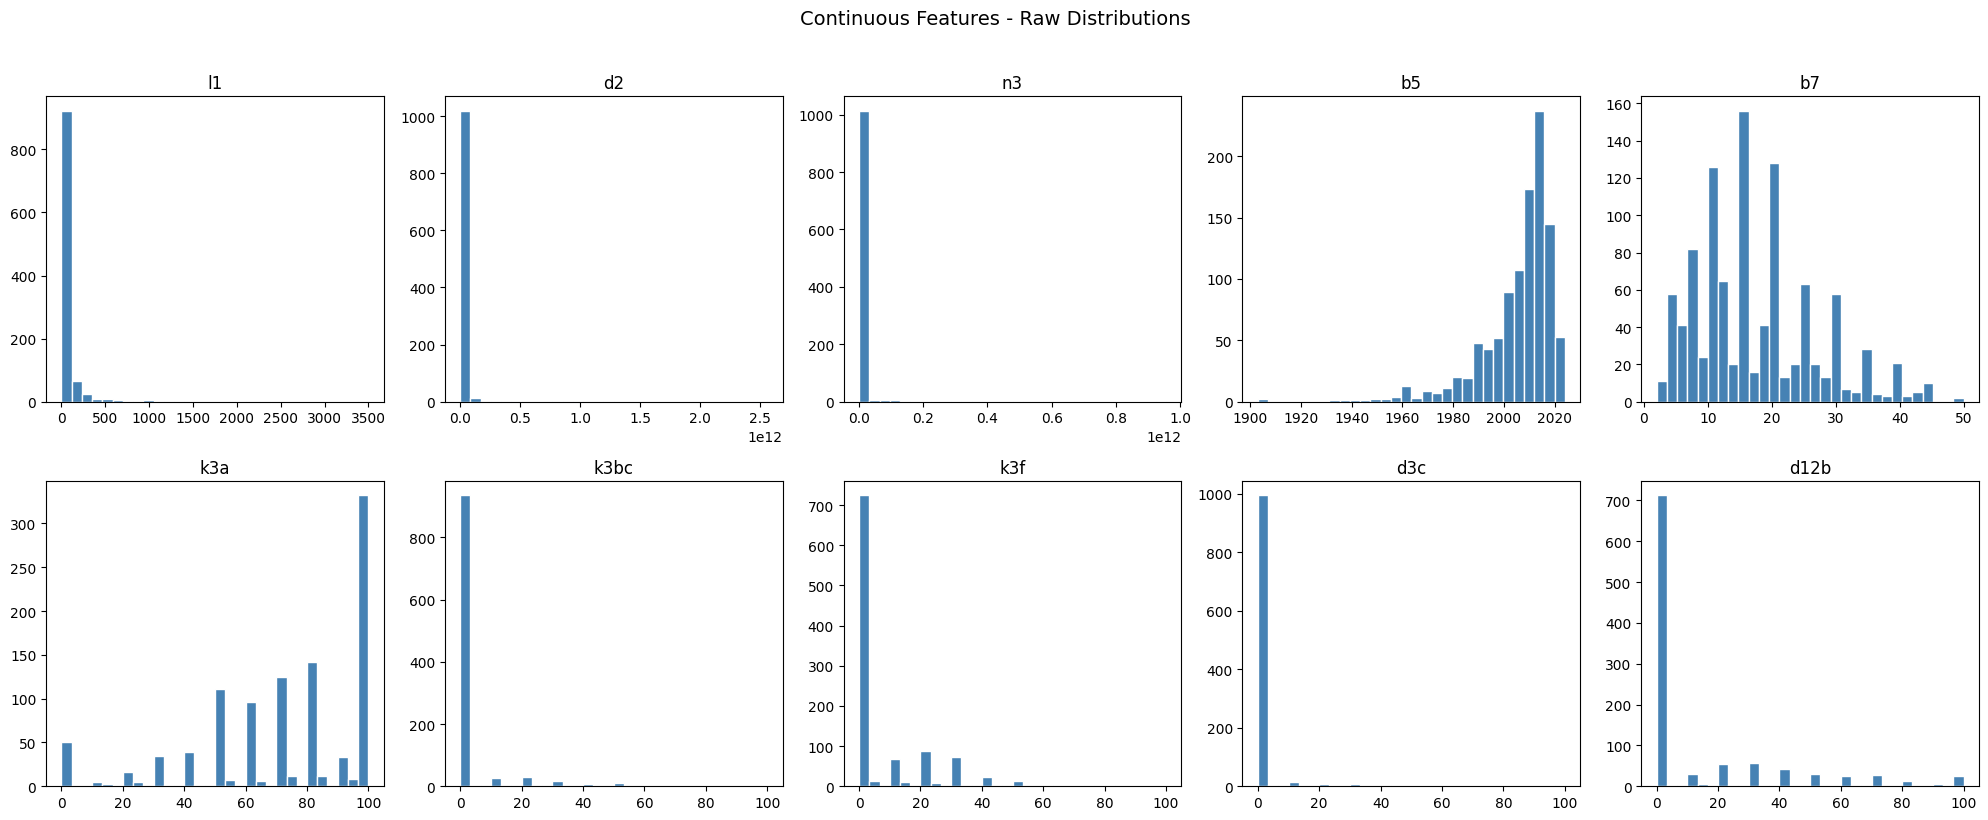

In [31]:
continuous = ['l1', 'd2', 'n3', 'b5', 'b7', 'k3a', 'k3bc', 'k3f', 'd3c', 'd12b']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    axes[i].hist(df_sel[col], bins=30, edgecolor='white', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features - Raw Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/dist_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

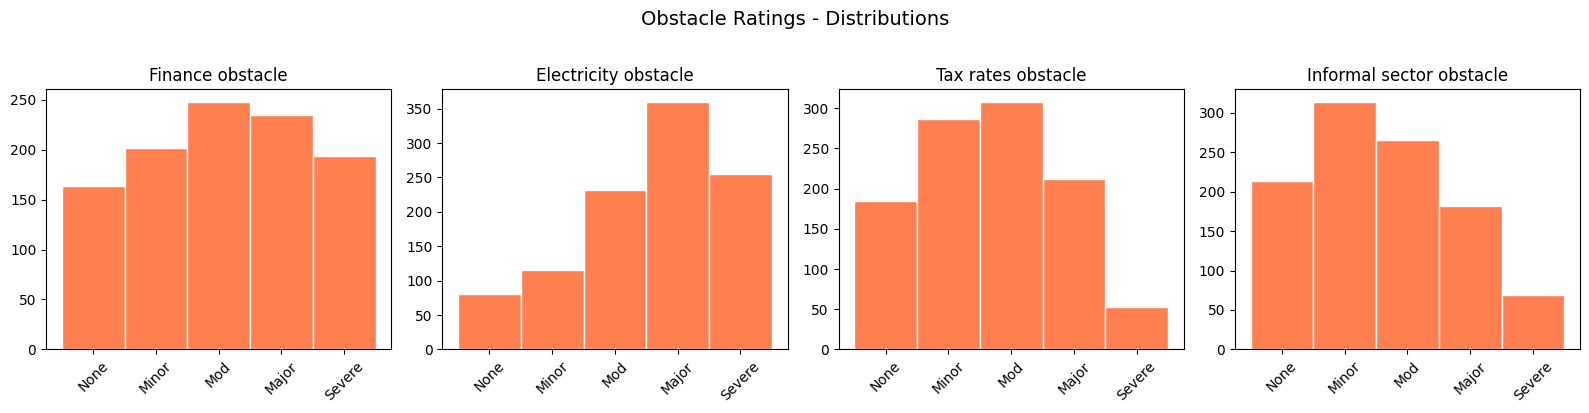

In [32]:
ordinal = ['k30', 'c30a', 'j30a', 'e30']
labels = ['Finance obstacle', 'Electricity obstacle', 'Tax rates obstacle', 'Informal sector obstacle']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (col, label) in enumerate(zip(ordinal, labels)):
    axes[i].hist(df_sel[col], bins=[0,1,2,3,4,5], edgecolor='white', 
                 color='coral', align='left')
    axes[i].set_title(label)
    axes[i].set_xticks([0,1,2,3,4])
    axes[i].set_xticklabels(['None','Minor','Mod','Major','Severe'], rotation=45)

plt.suptitle('Obstacle Ratings - Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/dist_ordinal.png', dpi=150, bbox_inches='tight')
plt.show()

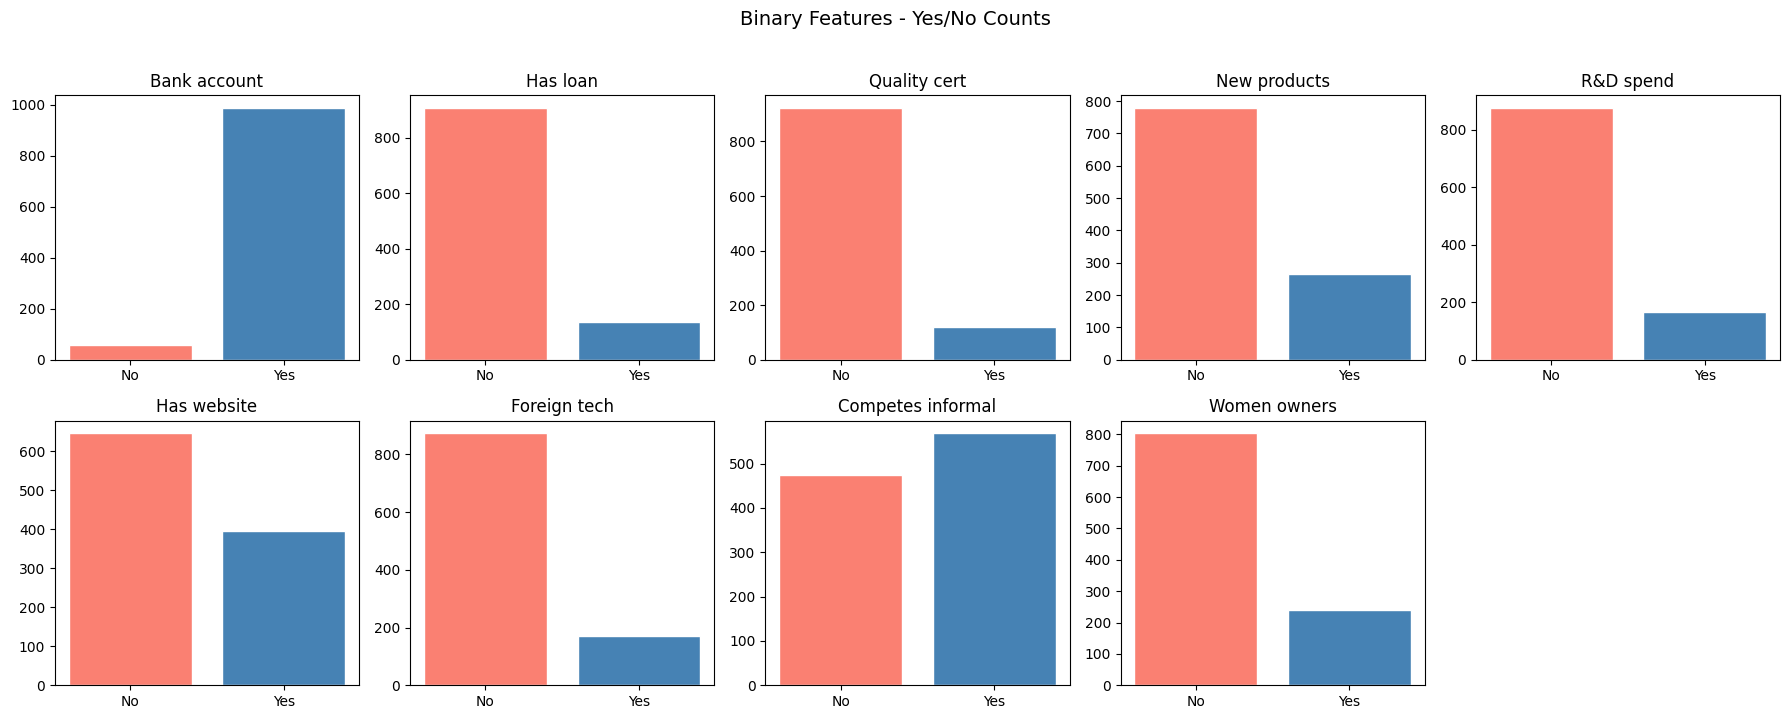

In [33]:
binary = ['k6', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4']
binary_labels = ['Bank account', 'Has loan', 'Quality cert', 
                 'New products', 'R&D spend', 'Has website',
                 'Foreign tech', 'Competes informal', 'Women owners']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(binary, binary_labels)):
    counts = df_sel[col].value_counts().sort_index()
    axes[i].bar(['No', 'Yes'], counts.values, color=['salmon', 'steelblue'], 
                edgecolor='white')
    axes[i].set_title(label)

# hide the unused subplot
axes[-1].set_visible(False)

plt.suptitle('Binary Features - Yes/No Counts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/dist_binary.png', dpi=150, bbox_inches='tight')
plt.show()

**Findings from distributions:**

**Continuous features** - `d2`, `n3`, and `l1` are severely right-skewed with values in the trillions for sales figures. Most firms are small with a long tail of larger firms. This is expected for SME data. The problem for K-Means is that Euclidean distance is scale-sensitive. A firm with 3,000 employees would dominate distance calculations even if it is just one observation. Log transformation compresses the tail and brings all continuous features onto a comparable scale.

**Obstacle ratings** - distributions are usable as-is. Electricity skews toward major/severe, which reflects Nigeria's infrastructure reality. Tax and informal sector are more evenly spread. No transformation needed.

**Binary features** - class imbalance is expected and not a problem for clustering the way it would be for classification. The concern is near-constant features. A column that is 94% one value contributes almost no separation between clusters. We will check variance before deciding what to keep.

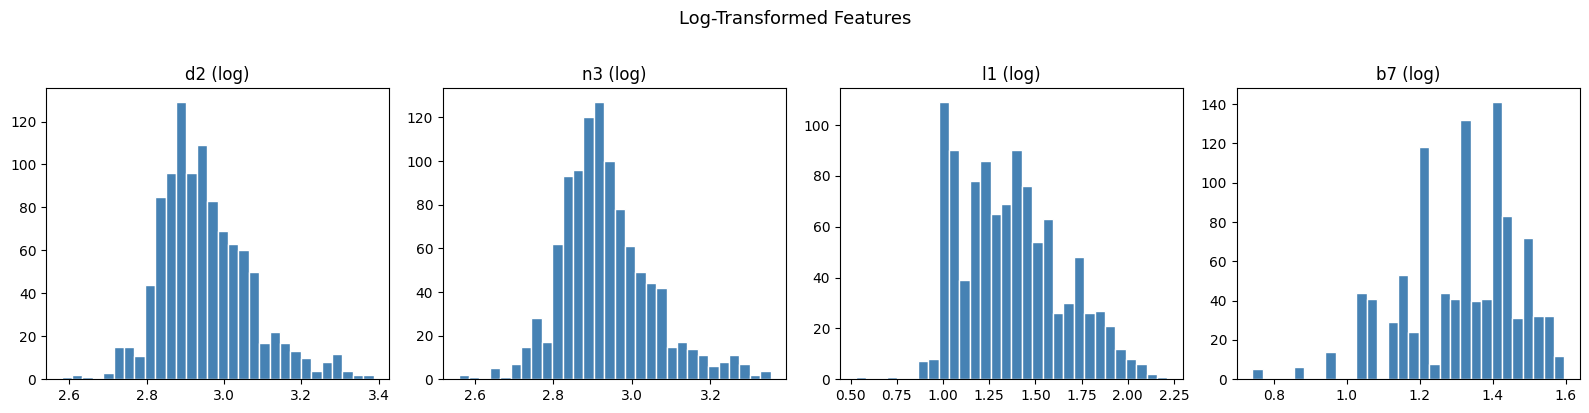

In [35]:
# d2 and n3 are in trillions - log transform to bring onto a comparable scale
# l1 and b7 are right skewed - same treatment
# adding 1 before log to handle any zero values safely
log_cols = ['d2', 'n3', 'l1', 'b7']

for col in log_cols:
    df_sel[col] = np.log1p(df_sel[col])

# replot to confirm
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(log_cols):
    axes[i].hist(df_sel[col], bins=30, edgecolor='white', color='steelblue')
    axes[i].set_title(f'{col} (log)')

plt.suptitle('Log-Transformed Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/dist_log_transformed.png', dpi=150, bbox_inches='tight')
plt.show()

Log transforms improved all four distributions significantly. `d2` and `n3` went from trillion-scale spikes to approximately bell-shaped curves. `l1` and `b7` are still right-skewed but much more manageable.

### Binary Feature Variance Check

Any binary feature with variance below 0.05 is near-constant and adds noise rather than signal.

In [36]:
binary = ['k6', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4']

variance = df_sel[binary].var().sort_values()
print(variance)

k6      0.050857
b8      0.101913
k82a    0.113500
h8      0.134607
e6      0.136556
b4      0.177327
h1      0.189230
c22b    0.235978
e11     0.248250
dtype: float64


**`k6` (bank account) has variance of 0.051 - borderline at best.**

94% of firms have a bank account. This column barely distinguishes firms from each other. Keeping it adds a weak, near-constant dimension to distance calculations with almost no clustering benefit. Drop it.

In [37]:
# k6 variance is 0.051 - 94% of firms have a bank account
# near-constant, adds almost no cluster separation
df_sel = df_sel.drop(columns=['k6'])

print(f"Final feature set: {df_sel.shape[1]} features, {df_sel.shape[0]} firms")
print(df_sel.columns.tolist())

Final feature set: 22 features, 1043 firms
['l1', 'd2', 'n3', 'k3a', 'k3bc', 'k3f', 'd3c', 'd12b', 'b5', 'b7', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4', 'k30', 'c30a', 'j30a', 'e30']


## 6. Correlation Analysis

With 21 features remaining, we check for redundancy. Highly correlated pairs (above 0.80) are near-duplicates - keeping both double-weights that signal in the clustering.

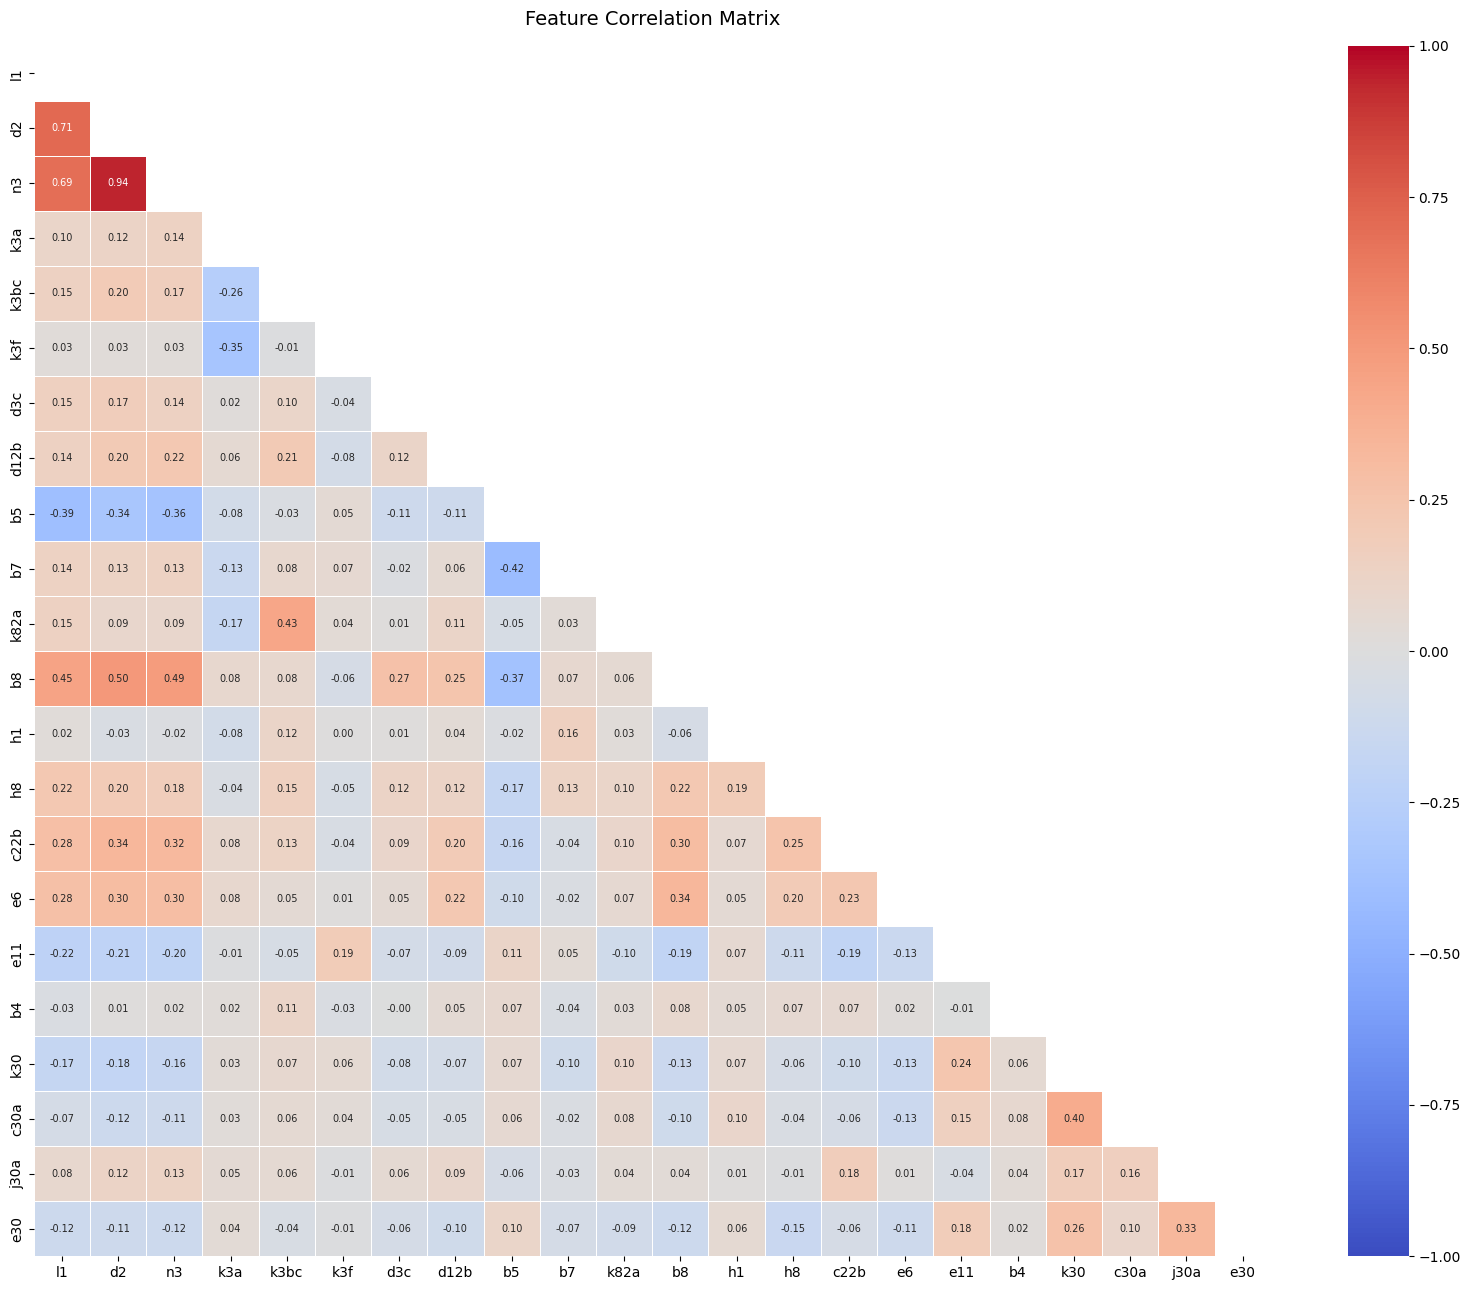

In [38]:
fig, ax = plt.subplots(figsize=(16, 13))

corr = df_sel.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**One pair breaches the 0.80 threshold: `d2` and `n3` at 0.94.**

Current sales and sales 3 years ago are almost the same signal. Firms large today were large 3 years ago. Keeping both would make firm size the dominant axis in every cluster.

The better move is to engineer a single `sales_growth` feature: `log(d2) - log(n3)`. Since both are already log-transformed, this is just subtraction. The result captures whether a firm is growing, flat, or shrinking - something neither column captured individually, and more interesting for segment profiling.

Other notable correlations worth keeping in mind for profiling:
- `l1` with `d2`/`n3` at ~0.72 - larger firms have higher sales, expected
- `b8` (quality cert) with sales at ~0.50 - certified firms tend to be bigger
- `k3a` and `k3bc` at -0.26 - firms using internal funds rely less on bank credit, they are substitutes

Final feature set: 21 features, 1043 firms
['l1', 'k3a', 'k3bc', 'k3f', 'd3c', 'd12b', 'b5', 'b7', 'k82a', 'b8', 'h1', 'h8', 'c22b', 'e6', 'e11', 'b4', 'k30', 'c30a', 'j30a', 'e30', 'sales_growth']


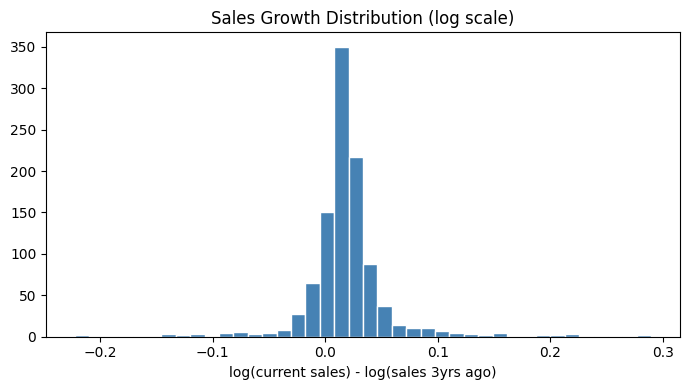

count    1043.000000
mean        0.018845
std         0.040667
min        -0.222333
25%         0.006997
50%         0.016284
75%         0.028257
max         0.289564
Name: sales_growth, dtype: float64


In [39]:
# d2 and n3 correlate at 0.94 - near duplicate signal
# replace both with sales growth: log(d2) - log(n3)
# both are already log-transformed so this is just subtraction
# positive = growing, negative = shrinking, zero = flat
df_sel['sales_growth'] = df_sel['d2'] - df_sel['n3']
df_sel = df_sel.drop(columns=['d2', 'n3'])

print(f"Final feature set: {df_sel.shape[1]} features, {df_sel.shape[0]} firms")
print(df_sel.columns.tolist())

# quick check on sales growth distribution
plt.figure(figsize=(7, 4))
plt.hist(df_sel['sales_growth'], bins=40, edgecolor='white', color='steelblue')
plt.title('Sales Growth Distribution (log scale)')
plt.xlabel('log(current sales) - log(sales 3yrs ago)')
plt.tight_layout()
plt.savefig('../outputs/figures/dist_sales_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_sel['sales_growth'].describe())

In [40]:
df_sel.to_csv('../data/processed/sme_clean.csv', index=False)
print("Saved to data/processed/sme_clean.csv")

Saved to data/processed/sme_clean.csv


## Summary

EDA complete. The cleaned dataset is saved to `data/processed/sme_clean.csv`.

**Final shape:** 1,043 firms, 21 features

**Decisions made during exploration:**

| Decision | Reason |
|---|---|
| Dropped `f1` (capacity utilization) | 58.7% missing - imputation would fabricate majority |
| Dropped `l5` (women employees) | 41.3% missing - `b4` covers gender angle with 0% missing |
| Re-encoded 13 category columns manually | Stata string labels broke `pd.to_numeric` conversion |
| Median imputation for continuous and ordinal | Skewed distributions make mean unreliable |
| Mode imputation for binary | No meaningful median for 0/1 columns |
| Log-transformed `l1`, `b7`, `d2`, `n3` | Heavy right skew - trillion-scale sales would dominate distance |
| Dropped `k6` (bank account) | Variance 0.051 - 94% Yes, near-constant |
| Replaced `d2` and `n3` with `sales_growth` | Correlation 0.94 - near-duplicate signal |